# Lung detection in chest X-ray

Task: develop a model to automatically detect the lungs in a chest X-ray scan. Make use of a YOLO (You Only Look Once) single-shot network.

Context: Chest X-rays are the most commonly acquired image in medicine. Because of the difference in density between air, soft tissue and bone, the lungs appear much darker than their surroundings. Brighter regions in the lungs may indicate the presence of pathology.

See the following papers for more details on YOLO and the more recent YOLO9000 methods:
- You Only Look Once: Unified, Real-Time Object Detection [https://arxiv.org/abs/1506.02640]
- YOLO9000: Better, Faster, Stronger [https://arxiv.org/abs/1612.08242]

Import and make use of the opensource `pytorchyolo` package which can be found here: https://github.com/eriklindernoren/PyTorch-YOLOv3/

In [3]:
!pip3 install -q --upgrade torch torchvision pytorch_lightning lightning-fabric
# Enforce the Pillow version required by pytorchyolo
!pip3 install -q --upgrade ismi_utils pytorchyolo "Pillow>=9.1.0,<10.0.0" opencv-python==4.5.5.64 pandas
!pip3 install -q --upgrade numpy==1.23.5 #numpy==1.24.4

# Check key package versions
!pip list | grep -E 'torch|lightning|Pillow|numpy|opencv|pytorchyolo'

lightning-fabric                   2.5.1
lightning-utilities                0.14.2
numpy                              1.23.5
opencv-contrib-python              4.11.0.86
opencv-python                      4.5.5.64
opencv-python-headless             4.11.0.86
Pillow                             9.5.0
pytorch-lightning                  2.5.1
pytorchyolo                        1.7.0
torch                              2.6.0+cu124
torchaudio                         2.6.0+cu124
torchmetrics                       1.7.0
torchsummary                       1.5.1
torchvision                        0.21.0+cu124


In [4]:
import torch
import pytorch_lightning as pl
from pytorchyolo.models import Darknet
from pytorchyolo.detect import detect_image
from pytorchyolo.utils.loss import compute_loss
from pytorchyolo.utils.utils import rescale_boxes, non_max_suppression

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
%matplotlib inline

from tqdm.notebook import tqdm
import numpy as np
import json
import pickle
import time
import random
import xml.etree.ElementTree as ET
from pathlib import Path
from ismi_utils import download_data
from PIL import Image
from torch.utils.data import random_split, DataLoader, Dataset
import pandas as pd
import shutil
import gc

## The data

The data we will use is from the CHESTXRAY14 dataset, which is publicly available and can be found at this link: https://nihcc.app.box.com/v/ChestXray-NIHCC

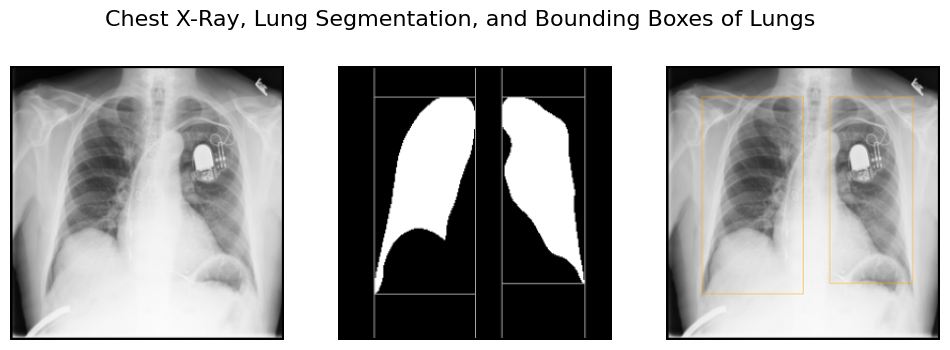

In [6]:
# Load images using OpenCV (or use PIL if preferred)
image1 = cv2.imread("chest-xray.png")
image2 = cv2.imread("lung-segmentation.png")
image3 = cv2.imread("bounding-box.png")

# Convert BGR to RGB (Colab uses RGB)
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
image3 = cv2.cvtColor(image3, cv2.COLOR_BGR2RGB)

# Display images side by side
fig, ax = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 3 columns
fig.suptitle("Chest X-Ray, Lung Segmentation, and Bounding Boxes of Lungs", fontsize=16)


ax[0].imshow(image1)
ax[0].axis('off')
ax[1].imshow(image2)
ax[1].axis('off')
ax[2].imshow(image3)
ax[2].axis('off')

plt.show()

Bounding box data come in xml format, which is the format read by the YOLO training script used in this task

An xml file for bounding boxes of right and left lung has the following example format:
```xml
<annotation verified="no">
  <folder>Lungs</folder>
  <filename>00000004_000</filename>
  <source>
    <database>Unknown</database>
  </source>
  <size>
    <width>512</width>
    <height>512</height>
    <depth>1</depth>
  </size>
  <segmented>0</segmented>
  <object>
    <name>RL</name>
    <pose>Unspecified</pose>
    <truncated>0</truncated>
    <difficult>0</difficult>
    <bndbox>
      <xmin>64</xmin>
      <ymin>62</ymin>
      <xmax>256</xmax>
      <ymax>490</ymax>
    </bndbox>
  </object>
  <object>
    <name>LL</name>
    <pose>Unspecified</pose>
    <truncated>0</truncated>
    <difficult>0</difficult>
    <bndbox>
      <xmin>298</xmin>
      <ymin>78</ymin>
      <xmax>450</xmax>
      <ymax>502</ymax>
    </bndbox>
  </object>
</annotation>
```

The most important parameters for this task are:
- (width, height): image size
- (RL, LL): labels for Right Lung and Left Lung
- (xmin, xmax, ymin, ymax): coordinates of the top-left and bottom-right corners of the bounding box

## Downloading the data



In [7]:
workdir = Path(".")

file_name = Path("train_lung_detection.zip")
download_data(file_name, link='https://surfdrive.surf.nl/files/index.php/s/kwSOdtP4t3dh5vD/download')

file_name = Path("test_images_lung_detection.zip")
download_data(file_name, link='https://surfdrive.surf.nl/files/index.php/s/ZImBQSvSCpqF0i9/download')

100%|██████████| 939M/939M [01:02<00:00, 15.7MB/s]
100%|██████████| 310M/310M [00:25<00:00, 12.5MB/s]


### Task 1
Get familiar with the data:
- Visualize chest X-ray images from the training set
- Read bounding box data for identifying the right lung
- Plot the bounding box

### Task 2
- setup a PyTorch Lightning training pipeline
- train a YOLO network to detect right lungs
- decode the output tensor in order to extract bounding box information
- visualize the predicted bounding box

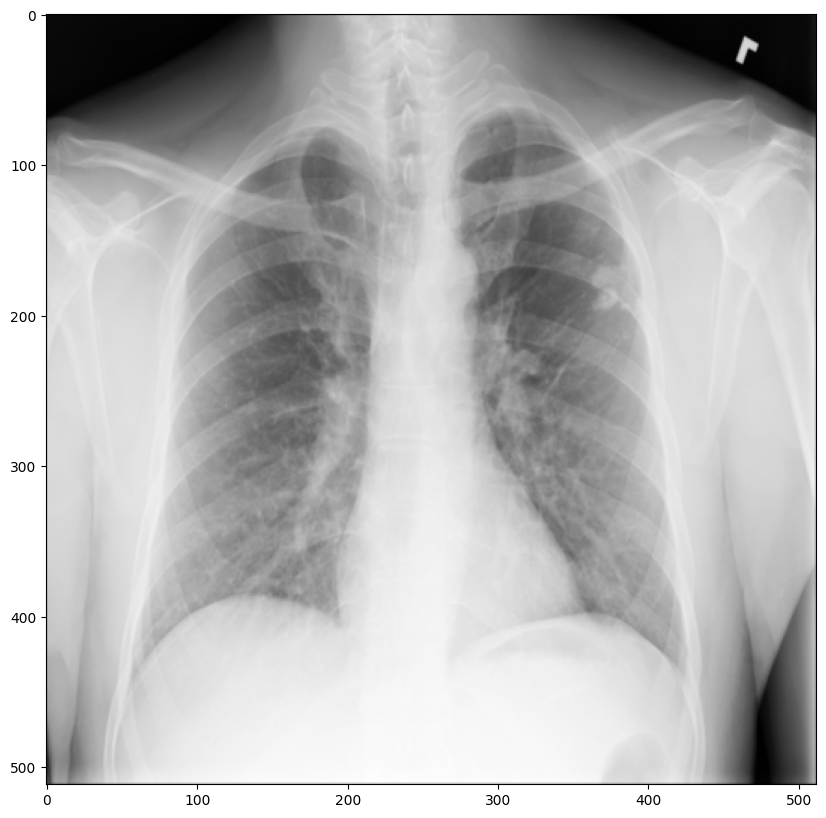

In [8]:
# Define directory of training images
train_dir_images = workdir / 'train' / 'images'

# Pick random training image
case = random.choice(list(train_dir_images.iterdir()))
case_filename = Path(case.name).with_suffix('.xml')

# Open image with opencv and visualize it
with Image.open(case) as im:
    image = np.array(im)
plt.figure(figsize=(10,10))
plt.imshow(image, cmap="gray")
plt.show()

In [9]:
class BoundingBox:
    def __init__(self, x, y, w, h, c = None, classes = None):
        """
        A bounding box object.

        Args:
        x: x coordinate of the center of the box
        y: y coordinate of the center of the box
        w: width of the box
        h: height of the box
        """
        self.x     = x
        self.y     = y
        self.w     = w
        self.h     = h

        self.c     = c
        self.classes = classes

        self.label = -1
        self.score = -1

    def get_label(self):
        if self.label == -1:
            self.label = np.argmax(self.classes)
        return self.label

    def get_score(self):
        if self.score == -1:
            self.score = self.classes[self.get_label()]
        return self.score

In [10]:
def xml2bbox(xml_file):
    '''
    Convert xml file to bounding box

    Args:
    xml_file: Path to xml file

    Returns:
    bbox: A BoundingBox object with parameters derived from the xml file
    '''
    # Parse structure of XML file
    tree = ET.parse(xml_file)

    for elem in tree.iter():
        if 'width' in elem.tag:
            width = int(elem.text)
        if 'height' in elem.tag:
            height = int(elem.text)

        for attr in list(elem):

            if 'bndbox' in attr.tag:
                for dim in list(attr):
                    if 'xmin' in dim.tag:
                        xmin = int(dim.text)
                    if 'ymin' in dim.tag:
                        ymin = int(dim.text)
                    if 'xmax' in dim.tag:
                        xmax = int(dim.text)
                    if 'ymax' in dim.tag:
                        ymax = int(dim.text)

    x = (xmin + xmax) / (2 * width)
    y = (ymin + ymax) / (2 * height)
    w = (xmax - xmin) / width
    h = (ymax - ymin) / height

    return BoundingBox(x,y,w,h)

In [11]:
annotation_file = workdir / 'train' / 'xml_right' / case_filename
bbox = xml2bbox(annotation_file)

In [12]:
def get_matplotlib_boxes(boxes, img_shape):
    plt_boxes = []
    for box in boxes:
        xmin  = int((box.x - box.w/2) * img_shape[1])
        xmax  = int((box.x + box.w/2) * img_shape[1])
        ymin  = int((box.y - box.h/2) * img_shape[0])
        ymax  = int((box.y + box.h/2) * img_shape[0])
        plt_boxes.append(patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, fill=False, color='#00FF00', linewidth=2))
    return plt_boxes

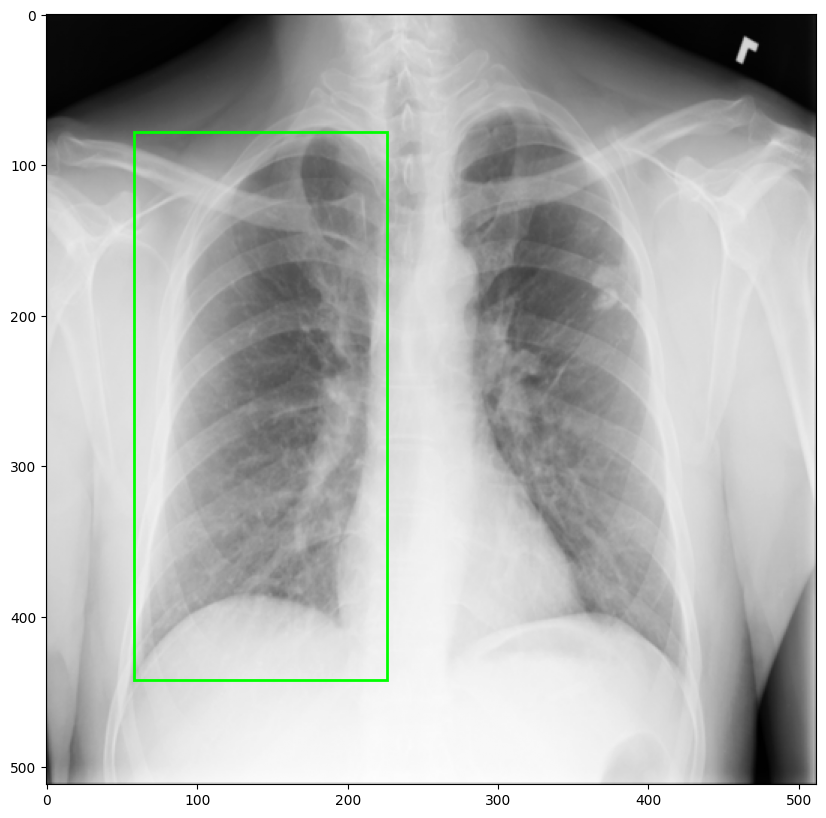

In [13]:
# Get bounding boxes in matplotlib format
plt_boxes = get_matplotlib_boxes([bbox], image.shape)

# Visualize image and bounding box
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, aspect='equal')
ax.imshow(image.squeeze(), cmap='gray')
for plt_box in plt_boxes:
    ax.add_patch(plt_box)
plt.show()

## Use the Pytorch Lightning framework and create a Datamodule
- Define a dataset for the right lung bounding box
- Define a Lightning Datamodule  that contains datasets and dataloaders for training, validating and testing models
- Define a LightningModule object to define our YOLO model

In [46]:
class RightLungDataset(Dataset):
    def __init__(self, image_dir, label_dir=None, transform=None):
        self.images = self.load_images(image_dir)
        self.case_ids = list(self.images.keys())
        if label_dir is not None:
            self.labels = self.load_labels(label_dir)
        else:
            self.labels = {case_id: [0, 0, 0, 0, 0] for case_id in self.case_ids}
        self.transform = transform

    def load_images(self, data_dir):
        images = {}
        for image_path in data_dir.iterdir():
            case_id = image_path.stem
            images[case_id] = image_path

            if len(images) == 2000:
                break
        return images

    def load_image(self, case_id):
        with Image.open(self.images[case_id]) as im:
            image = np.array(im).astype(np.uint8)
        return image

    def load_labels(self, data_dir):
        labels = {}
        for case_id in self.case_ids:
            annotation_file = workdir / 'train' / 'xml_right' / f"{case_id}.xml"
            bbox = xml2bbox(annotation_file)
            labels[case_id] = self.bbox_to_label(bbox)
        return labels

    def bbox_to_label(self, bbox):
        """convert to format [class x_center y_center width height]"""
        return [0, bbox.x, bbox.y, bbox.w, bbox.h]

    def visualize(self, idx):
        image, label = self[idx]

        # Remove channel dimension
        image = image[0]
        label = label[0]

        # Plot x-ray
        fig, ax = plt.subplots()
        ax.imshow(image, cmap="gray")

        # Plot box
        c, x, y, w, h = label
        xmin  = int((x - w/2) * image.shape[1])
        xmax  = int((x + w/2) * image.shape[1])
        ymin  = int((y - h/2) * image.shape[0])
        ymax  = int((y + h/2) * image.shape[0])
        plt_box = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, fill=False, color='#00FF00', linewidth=2)
        ax.add_patch(plt_box)

    def __getitem__(self, idx):
        case_id = self.case_ids[idx]
        image = self.load_image(case_id) / 255
        label = self.labels[case_id]

        # Add channel dimension to image
        image = image[None, ...]

        # Cast label to correct shape
        label = np.array(label).reshape(-1, 5)

        if self.transform:
            image = self.transform(image)

        return image, label

    def __len__(self):
        return len(self.images)

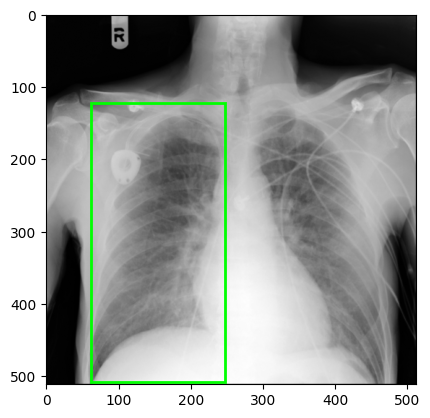

In [47]:
# Test your dataset implementation
train_dir = workdir / 'train'
right_lung_dataset = RightLungDataset(train_dir / "images", label_dir = train_dir / "xml_right")
right_lung_dataset.visualize(0)

In [48]:
class RightLungDatamodule(pl.LightningDataModule):
    def __init__(self, image_dir, label_dir, batch_size=8):
        super().__init__()
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.batch_size = batch_size
        self.train_fraction = 0.8

    def prepare_data(self):
        pass

    def setup(self, stage):
        full_set = RightLungDataset(self.image_dir, self.label_dir)
        train_size = int(self.train_fraction*len(full_set))
        val_size = len(full_set) - train_size
        self.train_dataset, self.val_dataset = random_split(full_set, [train_size, val_size])

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, collate_fn=self.collate_fn)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, collate_fn=self.collate_fn)

    def collate_fn(self, batch):
        images, labels = list(zip(*batch))

        # Stack images
        images = torch.stack([torch.tensor(image) for image in images])

        # Add sample index to targets
        final_labels = []
        for i, boxes in enumerate(labels):
            boxes = np.concatenate([np.zeros([len(boxes),1]), boxes], axis = 1)
            boxes[:, 0] = i
            final_labels.append(torch.tensor(boxes))
        labels = torch.cat(final_labels, 0)

        return images, labels

In [49]:
class YOLOv3(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = Darknet("yolov3-tiny.cfg")

    def forward(self, x):
        prediction = self.model(x.float())
        return prediction

    def training_step(self, batch, batch_idx):
        image, label = batch
        prediction = self.forward(image)
        loss, _ = compute_loss(prediction, label, self.model)

        self.log("train_loss", loss, on_step=False, on_epoch=True)

        return loss

    def validation_step(self, batch, batch_idx):
        self.train()
        image, label = batch
        prediction = self.forward(image)
        loss, _ = compute_loss(prediction, label, self.model)

        self.log("val_loss", loss, on_step=False, on_epoch=True)

        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")
!nvcc --version
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CUDA available: True
GPU name: Tesla T4
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [50]:
# Initialize the model
yolo_v3_model = YOLOv3()

# Initialize the datamodule
datamodule = RightLungDatamodule(image_dir=train_dir / "images", label_dir = train_dir / "xml_right", batch_size=8)

# Empty the log directory and setup the logger
log_dir = Path("logs") / "right_lung" / "version_0"
if log_dir.is_dir():
    shutil.rmtree(log_dir)
logger = pl.loggers.CSVLogger("logs", name="right_lung", flush_logs_every_n_steps=1, version=0)

# Initialize trainer and train!
trainer = pl.Trainer(max_epochs=15, accelerator="gpu", devices=1, logger=logger, log_every_n_steps=1)
trainer.fit(yolo_v3_model, datamodule)

INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type    | Params | Mode 
------------------------------------------
0 | model | Darknet | 8.7 M  | train
------------------------------------------
8.7 M     Trainable params
0         Non-trainable params
8.7 M     Total params
34.678    Total estimated model params size (MB)
77        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


 Plot train and validation loss

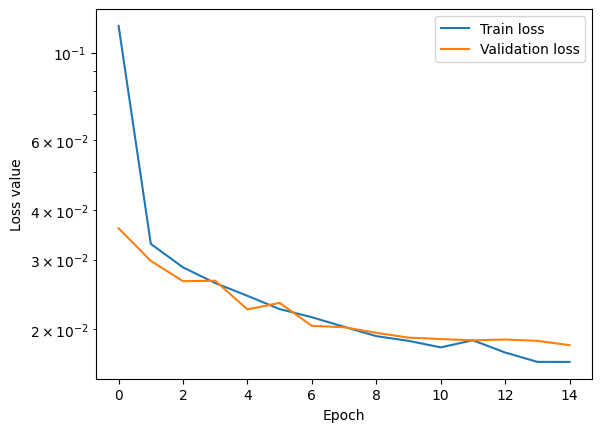

In [51]:
# Read the logged metrics.csv file
df = pd.read_csv(Path("logs") / "right_lung" / "version_0" / "metrics.csv")
train_loss = df.train_loss.dropna().values
val_loss = df.val_loss.dropna().values

# Make the plot
plt.figure()
plt.semilogy(train_loss, label="Train loss")
plt.semilogy(val_loss, label="Validation loss")
plt.ylabel("Loss value")
plt.xlabel("Epoch")
plt.legend()

In [52]:
# Pass single image through network
image, label = datamodule.train_dataset[0]
yolo_v3_model.train()
image = torch.tensor(image[None, ...])
raw_output = yolo_v3_model(image)[-1]
print(f"Raw output shape last yolo layer: {raw_output.shape}")

Raw output shape last yolo layer: torch.Size([1, 3, 32, 32, 6])


In [53]:
def single_inference(model, image, conf_thres=0.02, nms_thres=0.4):
    """
    Do inference on a single image

    Args:
    model: LightningModule
    image: 3d np.array
    conf_thres: Confidence threshold (between 0 and 1) for predicted boxes
    nms_thres: IoU threshold for non-maximum suppression

    Returns:
    boxes: list of BoundingBoxes objects
    """
    model.eval()
    image = torch.tensor(image[None, ...])

    with torch.no_grad():
        detections = model(image)
        detections = non_max_suppression(detections, conf_thres, nms_thres)
        detections = rescale_boxes(detections[0], 512, (512, 512))

    detections = detections.numpy()

    boxes = []
    for detection in detections:
        xmin, ymin, xmax, ymax, confidence, class_idx = detection
        w = int(xmax - xmin)
        h = int(ymax - ymin)
        x = int(xmin + w/2)
        y = int(ymin + h/2)
        boxes.append(BoundingBox(x / 512, y / 512, w / 512, h / 512, c=class_idx))

    return boxes

Plot 3 training and validation images

20968

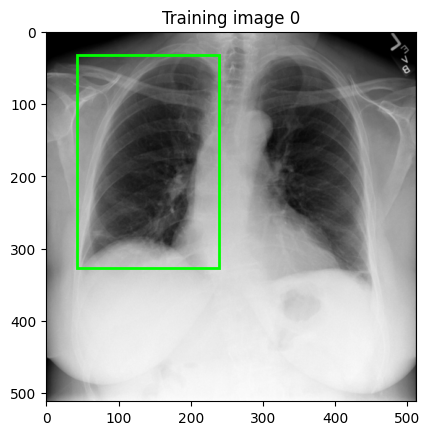

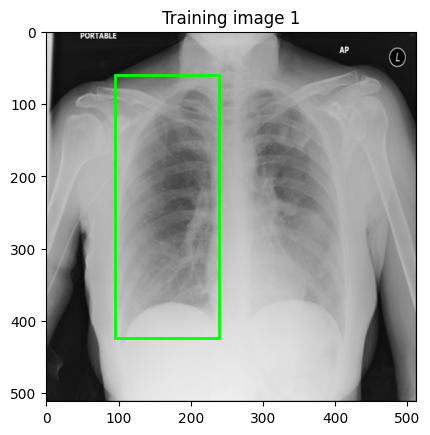

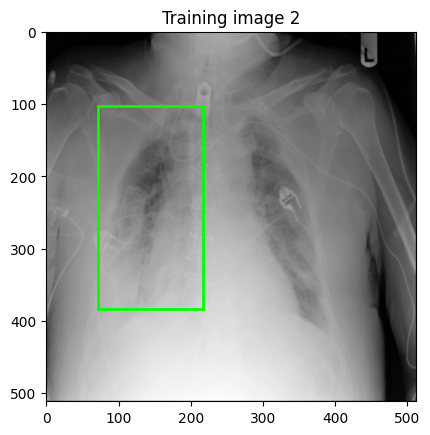

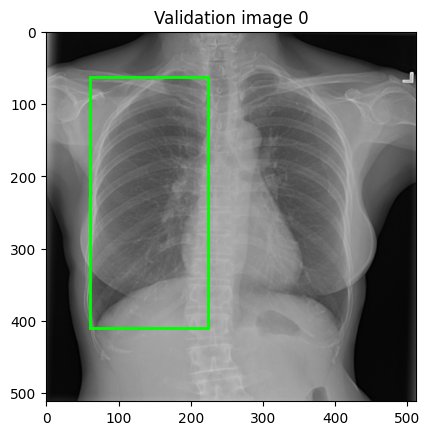

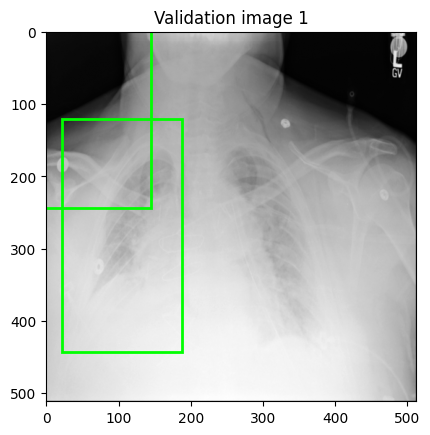

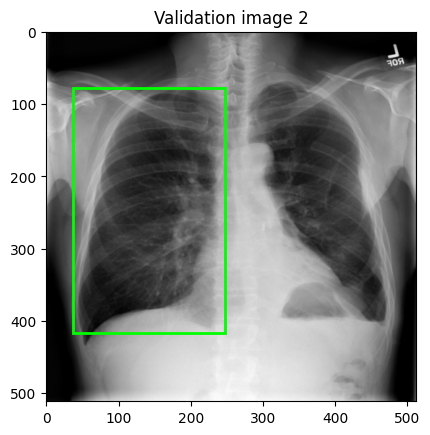

In [54]:
# Plot training images
for idx in range(3):
    image, label = datamodule.train_dataset[idx]
    boxes = single_inference(model=yolo_v3_model, image=image, conf_thres=0.01)

    # Get bounding boxes in matplotlib format
    plt_boxes = get_matplotlib_boxes(boxes,image[0].shape)

    # Visualize image and bounding box
    fig = plt.figure()
    ax = fig.add_subplot(111, aspect='equal')
    plt.imshow(image.squeeze(), cmap='gray')
    for plt_box in plt_boxes:
        ax.add_patch(plt_box)

    plt.title(f"Training image {idx}")

# Plot validation images
for idx in range(3):
    image, label = datamodule.val_dataset[idx]
    boxes = single_inference(model=yolo_v3_model, image=image, conf_thres=0.01)

    # Get bounding boxes in matplotlib format
    plt_boxes = get_matplotlib_boxes(boxes,image[0].shape)

    # Visualize image and bounding box
    fig = plt.figure()
    ax = fig.add_subplot(111, aspect='equal')
    plt.imshow(image.squeeze(), cmap='gray')
    for plt_box in plt_boxes:
        ax.add_patch(plt_box)
    plt.title(f"Validation image {idx}")

gc.collect()  # This prevents RAM from filling up each time we run this cell

18575

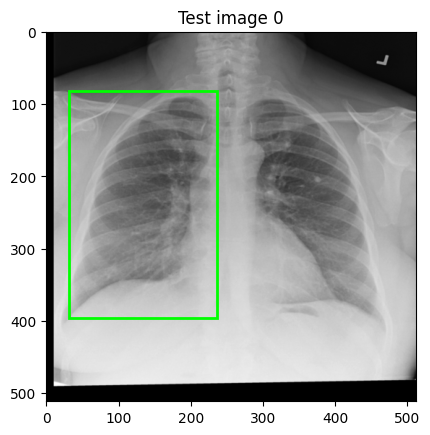

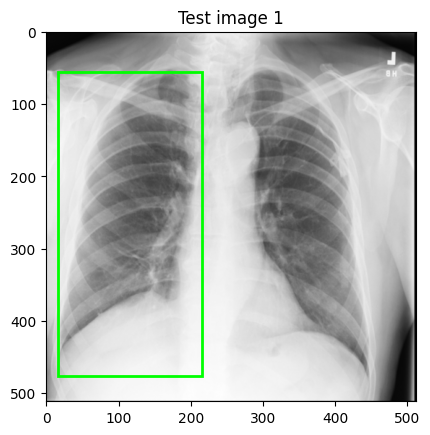

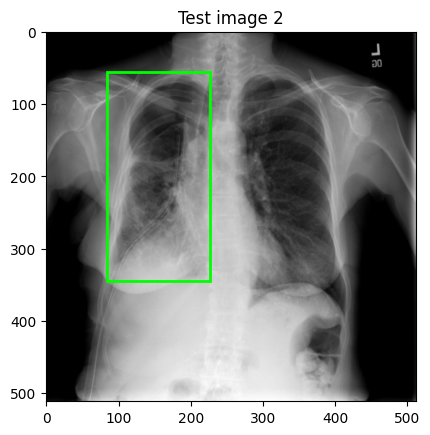

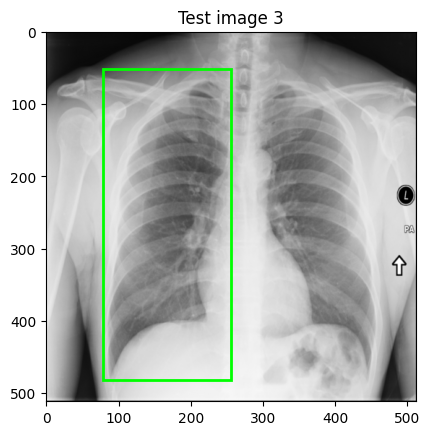

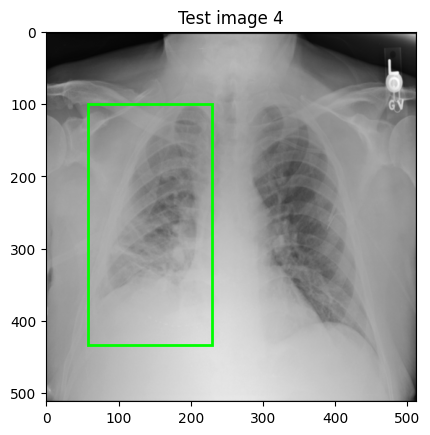

In [55]:
test_dir = workdir / 'test_images'
test_dataset = RightLungDataset(test_dir)

conf_thres = 0.05

# Plot sample test images
for idx in range(5):
    image, label = test_dataset[idx]
    boxes = single_inference(yolo_v3_model, image, conf_thres = conf_thres)

    # Get bounding boxes in matplotlib format
    plt_boxes = get_matplotlib_boxes(boxes,image[0].shape)

    # Visualize image and bounding box
    fig = plt.figure()
    ax = fig.add_subplot(111, aspect='equal')
    plt.imshow(image.squeeze(), cmap='gray')
    for plt_box in plt_boxes:
        ax.add_patch(plt_box)
    plt.title(f"Test image {idx}")

gc.collect()  # This prevents RAM from filling up each time we run this cell